# Cookie Cats A/B 实验分析

**数据说明：** 公开数据集，非公司内部数据。出处：[Kaggle - Mobile Games A/B Testing Cookie Cats](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)（游戏 Cookie Cats，Tactile Entertainment）。安装时随机分到 gate_30 / gate_40；sum_gamerounds 是安装后 14 天总局数，不是关卡进度。本仓库为个人作品集分析，与官方无关。


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 数据预处理

In [2]:
df = pd.read_csv("data/cookie_cats.csv")

## 数据概览

In [3]:
df.head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [4]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## 分流情况

In [5]:
df.groupby('version').count()

,userid,sum_gamerounds,retention_1,retention_7
version,,,,
gate_30,44700,44700,44700,44700
gate_40,45489,45489,45489,45489


## 异常值处理

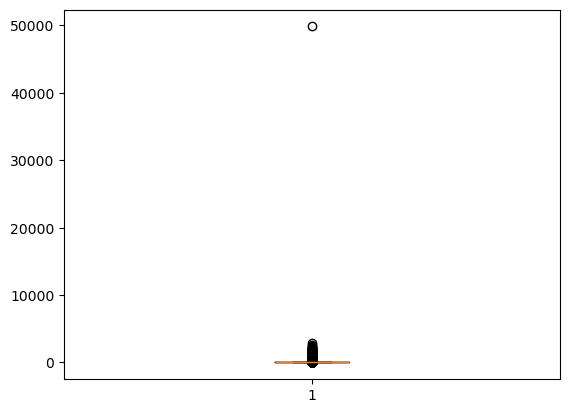

In [6]:
plt.boxplot(df['sum_gamerounds'])
plt.show()

In [7]:
max_val = df['sum_gamerounds'].max()
df = df[df['sum_gamerounds'] != max_val]

In [8]:
df.describe()

,userid,sum_gamerounds
count,9.018800e+04,90188.000000
mean,4.998397e+06,51.320253
std,2.883298e+06,102.682719
min,1.160000e+02,0.000000
25%,2.512211e+06,5.000000
50%,4.995804e+06,16.000000
75%,7.496461e+06,51.000000
max,9.999861e+06,2961.000000


# AB实验

## 明确实验目标与核心指标

- 业务目标：确定第一个 gate 放在第 30 关还是第 40 关更有利于玩家留存
- 指标选取：  
	核心指标：`retention_7` 七日留存（业务最关心长期留存）   
	次要指标：`retention_1`次日留存；`sum_gamerounds` 14 天游玩总回合   
	护栏指标：付费转化率、用户流失率（游戏内主动退出、卸载） 注：本数据不含付费/卸载，护栏缺失 
- 实验假设
	- 原假设：gate_30 和 gate_40 的七日留存率没有差异
	- 备择假设：两组指标有差异
- 分流单位：用户粒度

## 选取实验方法

留存率是比例指标，且样本量足够大（近似正态），采取两样本Z检验，并进行Bootstrap进行稳健检验

## 计算最小样本量和实验周期

- 固有数据
	- $p_{1}$：对照组的预期比例
	- $p_{2}$：实验组的预期比例，$p_{2}=p_{1}+\Delta$
- 需与业务方敲定
	- $\Delta=|p_{1}-p_{2}|$：最小可检测效应，需与业务方敲定，多大的提升才算有业务价值，值得投入资源上线。MDE太大，可能错过有价值的小幅提升；MDE太小，可能需要的样本量巨大；本项目取绝对效应1%
	- 显著性水平$\alpha$：容许犯第一类错误的概率，错误的认为有差异的风险；本项目取0.05
	- 统计功效$1-\beta$：通常取行业标准0.8，表示我们希望有多大把握检测出真实存在的效应。
- 按公式计算最小样本量，
	$$n_{1}=\frac{{\left( z_{1-\frac{\alpha}{2}}\sqrt{ V_{0} }+z_{1-\beta} \sqrt{ V_{1} }\right)^2}}{\Delta^2}$$

	$$V=\sigma_{1}^2+\frac{\sigma_{2}^2}{k}$$
	通常假设$V_{0}≈V_{1}=V$$$
n_{1}=\frac{{\left( z_{1-\frac{\alpha}{2}}+z_{1-\beta} \right)^2*V}}{\Delta^2}
$$
	- 当为均值指标时，若两组标准差近似为s，$V≈2s^2$
	- 当为比例型指标时，假设$p=p_{1}≈p_{2}$近似两组，$V≈\left( 1+\frac{1}{k}\right)p(1-p)=2p(1-p)$
	- $n_{2}=k*n_{1}$
- 实验周期=最小样本量/日均流量，注意考虑周期性影响 

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.stats.proportion import samplesize_proportions_2indep_onetail


control = df[df['version'] == 'gate_30']

# =========================
# 1. 参数设置
# =========================
alpha = 0.05        # 显著性水平（双边）
power = 0.80        # 统计功效
delta = 0.01        # 绝对 MDE = 1 个百分点
k = 1               # 两组 1:1 分流

z_alpha = norm.ppf(1 - alpha / 2)   # 1.95996
z_beta = norm.ppf(power)            # 0.84162

# =========================
# 2. 方法一：手推公式
# =========================
def min_sample_size_manual_full(p1, delta, alpha=0.05, power=0.8, k=1):
    """
    比例指标最小样本量（完整手推公式）
    n1 = (z_{1-alpha/2} * sqrt(V0) + z_{1-beta} * sqrt(V1))^2 / delta^2

    V0: 原假设下方差
    V1: 备择假设下方差
    """
    p2 = p1 + delta
    p_bar = (p1 + k * p2) / (1 + k)   # 合并比例

    z_a = norm.ppf(1 - alpha / 2)
    z_b = norm.ppf(power)

    # 原假设 H0: p1 = p2 = p_bar
    V0 = p_bar * (1 - p_bar) * (1 + 1 / k)

    # 备择假设 H1: p1 != p2
    V1 = p1 * (1 - p1) + p2 * (1 - p2) / k

    n1 = ((z_a * np.sqrt(V0) + z_b * np.sqrt(V1)) ** 2) / (delta ** 2)
    n2 = k * n1
    total = n1 + n2

    return int(np.ceil(n1)), int(np.ceil(n2)), int(np.ceil(total))

# =========================
# 3. 方法二：statsmodels 自带函数
# =========================
def min_sample_size_statsmodels(p1, delta, alpha=0.05, power=0.8, ratio=1):
    """
    比例指标最小样本量（statsmodels）
    返回对照组 n1、实验组 n2、总样本量
    """
    n1 = samplesize_proportions_2indep_onetail(
        diff=delta,          # 绝对 MDE
        prop2=p1,            # 对照组基线比例
        power=power,
        ratio=ratio,
        alpha=alpha,
        alternative='two-sided'
    )
    n1 = int(np.ceil(n1))
    n2 = int(np.ceil(n1 * ratio))
    total = n1 + n2
    return n1, n2, total

# =========================
# 4. 对比两种方法
# =========================
print("=" * 75)
print(f"参数：alpha={alpha}, power={power}, delta={delta}, k={k}")
print("=" * 75)

results = []
for metric in ['retention_1', 'retention_7']:
    p1 = control[metric].mean()

    n1_m, n2_m, total_m = min_sample_size_manual_full(p1, delta, alpha, power, k)
    n1_s, n2_s, total_s = min_sample_size_statsmodels(p1, delta, alpha, power, k)

    results.append({
        '指标': metric,
        '基线 p': round(p1, 4),
        '手推 n1': n1_m,
        'statsmodels n1': n1_s,
        '差异': n1_s - n1_m,
        '手推总样本': total_m,
        'statsmodels总样本': total_s
    })

    print(f"\n指标: {metric}")
    print(f"  基线 p = {p1:.4f}")
    print(f"  方法一（完整手推公式）: n1 = {n1_m:,}, n2 = {n2_m:,}, 总计 = {total_m:,}")
    print(f"  方法二（statsmodels）:  n1 = {n1_s:,}, n2 = {n2_s:,}, 总计 = {total_s:,}")
    print(f"  差异: {n1_s - n1_m:+,}")

参数：alpha=0.05, power=0.8, delta=0.01, k=1

指标: retention_1
  基线 p = 0.4482
  方法一（完整手推公式）: n1 = 38,900, n2 = 38,900, 总计 = 77,799
  方法二（statsmodels）:  n1 = 38,900, n2 = 38,900, 总计 = 77,800
  差异: +0

指标: retention_7
  基线 p = 0.1902
  方法一（完整手推公式）: n1 = 24,658, n2 = 24,658, 总计 = 49,316
  方法二（statsmodels）:  n1 = 24,658, n2 = 24,658, 总计 = 49,316
  差异: +0


目前收集的样本量达到了最小样本量的要求

## SRM检验

In [10]:
from scipy.stats import chisquare

counts = df['version'].value_counts()
n_gate_30 = counts['gate_30']
n_gate_40 = counts['gate_40']
n_total = n_gate_30 + n_gate_40

print(f"gate_30: {n_gate_30:,}")
print(f"gate_40: {n_gate_40:,}")
print(f"总计:    {n_total:,}")
print()


# 预期比例：50% / 50%
expected_ratio = [0.5, 0.5]
expected_counts = [n_total * r for r in expected_ratio]

observed_counts = [n_gate_30, n_gate_40]

# 卡方拟合优度检验
chi2, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("=" * 60)
print("SRM 检验（卡方拟合优度检验）")
print("=" * 60)
print(f"观察频数: gate_30 = {n_gate_30:,}, gate_40 = {n_gate_40:,}")
print(f"期望频数: gate_30 = {expected_counts[0]:,.1f}, gate_40 = {expected_counts[1]:,.1f}")
print(f"卡方统计量 χ² = {chi2:.4f}")
print(f"自由度 df = 1")
print(f"p 值 = {p_value:.6f}")
print()

# =========================
# 判定 SRM
# =========================
alpha_srm = 0.001   # 常用严格阈值
alpha_srm_loose = 0.05  # 宽松阈值

print("判定：")
if p_value < alpha_srm:
    print(f"  p = {p_value:.6f} < {alpha_srm} → 存在严重 SRM，建议暂停分析，排查分流问题")
elif p_value < alpha_srm_loose:
    print(f"  {alpha_srm} < p = {p_value:.6f} < {alpha_srm_loose} → 存在轻微 SRM 迹象，需关注")
else:
    print(f"  p = {p_value:.6f} ≥ {alpha_srm_loose} → 未检测到 SRM，样本比例正常")
print()

# =========================
# 5. 计算实际分流比与偏差
# =========================
actual_ratio_30 = n_gate_30 / n_total
actual_ratio_40 = n_gate_40 / n_total

print("实际分流比例：")
print(f"  gate_30 = {actual_ratio_30:.4%}")
print(f"  gate_40 = {actual_ratio_40:.4%}")
print(f"  偏差 = {abs(actual_ratio_30 - 0.5):.4%}")
print()

gate_30: 44,699
gate_40: 45,489
总计:    90,188

SRM 检验（卡方拟合优度检验）
观察频数: gate_30 = 44,699, gate_40 = 45,489
期望频数: gate_30 = 45,094.0, gate_40 = 45,094.0
卡方统计量 χ² = 6.9200
自由度 df = 1
p 值 = 0.008524

判定：
  0.001 < p = 0.008524 < 0.05 → 存在轻微 SRM 迹象，需关注

实际分流比例：
  gate_30 = 49.5620%
  gate_40 = 50.4380%
  偏差 = 0.4380%



未达 0.001 的严重阈值，但有轻微 SRM，分流记为风险。

## 双样本Z检验

In [11]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# =========================
# 分组统计
# =========================
control = df[df['version'] == 'gate_30']
treatment = df[df['version'] == 'gate_40']

n_control = len(control)
n_treatment = len(treatment)

print(f"gate_30 (对照组): n = {n_control:,}")
print(f"gate_40 (实验组): n = {n_treatment:,}")
print()

# =========================
# 双样本比例 Z 检验
# =========================
alpha = 0.05

for metric in ['retention_1', 'retention_7']:
    # 两组留存人数和留存率
    count_control = control[metric].sum()
    count_treatment = treatment[metric].sum()

    p_control = count_control / n_control
    p_treatment = count_treatment / n_treatment

    # 两独立样本比例 Z 检验（双边）
    z_stat, p_value = proportions_ztest(
        count=[count_control, count_treatment],
        nobs=[n_control, n_treatment],
        alternative='two-sided'
    )

    # 比例差和置信区间
    diff = p_treatment - p_control
    ci_low, ci_high = confint_proportions_2indep(
        count1=count_treatment, nobs1=n_treatment,
        count2=count_control, nobs2=n_control,
        method='wald',
        alpha=alpha
    )

    # 相对变化
    rel_diff = diff / p_control

    print("=" * 65)
    print(f"指标: {metric}")
    print("=" * 65)
    print(f"  gate_30 留存率 = {p_control:.4f} ({p_control*100:.2f}%)")
    print(f"  gate_40 留存率 = {p_treatment:.4f} ({p_treatment*100:.2f}%)")
    print(f"  绝对差异 = {diff:+.4f} ({diff*100:+.2f} 个百分点)")
    print(f"  相对变化 = {rel_diff:+.2%}")
    print(f"  Z 统计量 = {z_stat:.4f}")
    print(f"  p 值 = {p_value:.6f}")
    print(f"  95% CI (gate_40 - gate_30) = [{ci_low:+.4f}, {ci_high:+.4f}]")
    print()

    # 显著性判断
    if p_value < alpha:
        if diff > 0:
            print(f"  结论: 在 α={alpha} 下，gate_40 显著高于 gate_30")
        else:
            print(f"  结论: 在 α={alpha} 下，gate_40 显著低于 gate_30")
    else:
        print(f"  结论: 在 α={alpha} 下，两组无显著差异")
    print()

# =========================
# 汇总表
# =========================
results = []
for metric in ['retention_1', 'retention_7']:
    count_control = control[metric].sum()
    count_treatment = treatment[metric].sum()
    p_control = count_control / n_control
    p_treatment = count_treatment / n_treatment
    diff = p_treatment - p_control

    z_stat, p_value = proportions_ztest(
        count=[count_control, count_treatment],
        nobs=[n_control, n_treatment],
        alternative='two-sided'
    )
    ci_low, ci_high = confint_proportions_2indep(
        count1=count_treatment, nobs1=n_treatment,
        count2=count_control, nobs2=n_control,
        method='wald', alpha=alpha
    )

    results.append({
        '指标': metric,
        'gate_30': round(p_control, 4),
        'gate_40': round(p_treatment, 4),
        '绝对差异': round(diff, 4),
        '相对变化': f"{diff/p_control:+.2%}",
        'Z': round(z_stat, 4),
        'p值': round(p_value, 6),
        'CI下限': round(ci_low, 4),
        'CI上限': round(ci_high, 4),
        '显著': '是' if p_value < alpha else '否'
    })

print("=" * 65)
print("汇总表")
print("=" * 65)
print(pd.DataFrame(results).to_string(index=False))

gate_30 (对照组): n = 44,699
gate_40 (实验组): n = 45,489

指标: retention_1
  gate_30 留存率 = 0.4482 (44.82%)
  gate_40 留存率 = 0.4423 (44.23%)
  绝对差异 = -0.0059 (-0.59 个百分点)
  相对变化 = -1.32%
  Z 统计量 = 1.7871
  p 值 = 0.073921
  95% CI (gate_40 - gate_30) = [-0.0124, +0.0006]

  结论: 在 α=0.05 下，两组无显著差异

指标: retention_7
  gate_30 留存率 = 0.1902 (19.02%)
  gate_40 留存率 = 0.1820 (18.20%)
  绝对差异 = -0.0082 (-0.82 个百分点)
  相对变化 = -4.30%
  Z 统计量 = 3.1574
  p 值 = 0.001592
  95% CI (gate_40 - gate_30) = [-0.0133, -0.0031]

  结论: 在 α=0.05 下，gate_40 显著低于 gate_30

汇总表
         指标  gate_30  gate_40    绝对差异   相对变化      Z       p值    CI下限    CI上限 显著
retention_1   0.4482   0.4423 -0.0059 -1.32% 1.7871 0.073921 -0.0124  0.0006  否
retention_7   0.1902   0.1820 -0.0082 -4.30% 3.1574 0.001592 -0.0133 -0.0031  是


## 综合评估与决策建议

检验结果：
次日留存率retention_1
- p = 0.0739 > 0.05，未达显著，CI 为 −1.24pp,+0.06pp，排不掉约 1pp 的下降；决策看预注册的七日留存。

七日留存率retention_7
- p = 0.0016 < 0.05，**显著**
- 95% CI 完全不包含 0，且上下限都是负数
- 说明 gate_40 的 7 日留存真实低于 gate_30

业务建议：不建议把 gate 从第 30 关移到第 40 关。

理由：
1. 1 日留存没有提升，甚至点估计略低。
2. 7 日留存显著下降，这是更重要的长期指标。

## Bootstrap检验结果稳健性

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

control = df[df['version'] == 'gate_30']
treatment = df[df['version'] == 'gate_40']

# =========================
# Bootstrap 函数
# =========================
def bootstrap_diff(
    control_values,
    treatment_values,
    n_bootstrap=10000,
    alpha=0.05,
    random_state=42
):
    """
    对两组二值指标做 Bootstrap，估计留存率差值的分布和置信区间。
    
    参数:
        control_values: 对照组 0/1 数组
        treatment_values: 实验组 0/1 数组
        n_bootstrap: 重抽样次数
        alpha: 显著性水平
        random_state: 随机种子
    
    返回:
        dict，包含差值点估计、CI、标准误
    """
    rng = np.random.default_rng(random_state)
    
    n_control = len(control_values)
    n_treatment = len(treatment_values)
    
    # 原始点估计
    p_control = control_values.mean()
    p_treatment = treatment_values.mean()
    observed_diff = p_treatment - p_control
    
    # Bootstrap 重抽样
    boot_diffs = np.empty(n_bootstrap)
    
    for i in range(n_bootstrap):
        boot_control = rng.choice(control_values, size=n_control, replace=True)
        boot_treatment = rng.choice(treatment_values, size=n_treatment, replace=True)
        boot_diffs[i] = boot_treatment.mean() - boot_control.mean()
    
    # 置信区间（percentile 方法）
    ci_low = np.percentile(boot_diffs, 100 * alpha / 2)
    ci_high = np.percentile(boot_diffs, 100 * (1 - alpha / 2))
    
    # Bootstrap 标准误
    se = boot_diffs.std(ddof=1)
    
    return {
        'p_control': p_control,
        'p_treatment': p_treatment,
        'observed_diff': observed_diff,
        'boot_diffs': boot_diffs,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'se': se
    }

# =========================
# 对两个指标分别做 Bootstrap
# =========================
n_bootstrap = 10000
alpha = 0.05

print("=" * 70)
print(f"Bootstrap 分析（n_bootstrap = {n_bootstrap:,}）")
print("=" * 70)

results = []

for metric in ['retention_1', 'retention_7']:
    control_values = control[metric].astype(int).values
    treatment_values = treatment[metric].astype(int).values
    
    res = bootstrap_diff(
        control_values,
        treatment_values,
        n_bootstrap=n_bootstrap,
        alpha=alpha,
        random_state=42
    )
    
    diff = res['observed_diff']
    ci_low = res['ci_low']
    ci_high = res['ci_high']
    
    print(f"\n指标: {metric}")
    print(f"  gate_30 留存率 = {res['p_control']:.4f} ({res['p_control']*100:.2f}%)")
    print(f"  gate_40 留存率 = {res['p_treatment']:.4f} ({res['p_treatment']*100:.2f}%)")
    print(f"  绝对差异 = {diff:+.4f} ({diff*100:+.2f} 个百分点)")
    print(f"  Bootstrap 标准误 = {res['se']:.6f}")
    print(f"  95% CI = [{ci_low:+.4f}, {ci_high:+.4f}]")
    
    if ci_low > 0 or ci_high < 0:
        print(f"  结论: 95% CI 不包含 0，两组差异显著")
    else:
        print(f"  结论: 95% CI 包含 0，两组差异不显著")
    
    results.append({
        '指标': metric,
        'gate_30': round(res['p_control'], 4),
        'gate_40': round(res['p_treatment'], 4),
        '绝对差异': round(diff, 4),
        'Bootstrap SE': round(res['se'], 6),
        'CI下限': round(ci_low, 4),
        'CI上限': round(ci_high, 4),
        '显著': '是' if (ci_low > 0 or ci_high < 0) else '否'
    })

# =========================
# 汇总表
# =========================
print("\n" + "=" * 70)
print("Bootstrap 汇总表")
print("=" * 70)
print(pd.DataFrame(results).to_string(index=False))



Bootstrap 分析（n_bootstrap = 10,000）

指标: retention_1
  gate_30 留存率 = 0.4482 (44.82%)
  gate_40 留存率 = 0.4423 (44.23%)
  绝对差异 = -0.0059 (-0.59 个百分点)
  Bootstrap 标准误 = 0.003307
  95% CI = [-0.0124, +0.0007]
  结论: 95% CI 包含 0，两组差异不显著

指标: retention_7
  gate_30 留存率 = 0.1902 (19.02%)
  gate_40 留存率 = 0.1820 (18.20%)
  绝对差异 = -0.0082 (-0.82 个百分点)
  Bootstrap 标准误 = 0.002571
  95% CI = [-0.0134, -0.0032]
  结论: 95% CI 不包含 0，两组差异显著

Bootstrap 汇总表
         指标  gate_30  gate_40    绝对差异  Bootstrap SE    CI下限    CI上限 显著
retention_1   0.4482   0.4423 -0.0059      0.003307 -0.0124  0.0007  否
retention_7   0.1902   0.1820 -0.0082      0.002571 -0.0134 -0.0032  是


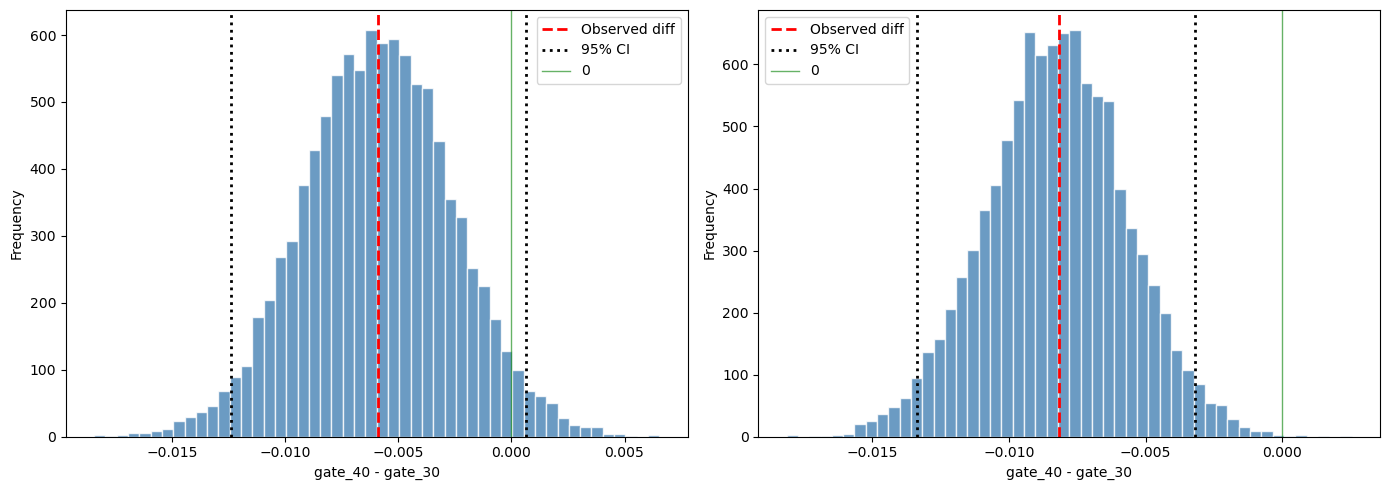

In [13]:
# =========================
# 可视化
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['retention_1', 'retention_7']):
    control_values = control[metric].astype(int).values
    treatment_values = treatment[metric].astype(int).values
    
    res = bootstrap_diff(
        control_values, treatment_values,
        n_bootstrap=n_bootstrap, alpha=alpha, random_state=42
    )
    
    ax.hist(res['boot_diffs'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(res['observed_diff'], color='red', linestyle='--', linewidth=2, label='Observed diff')
    ax.axvline(res['ci_low'], color='black', linestyle=':', linewidth=2, label='95% CI')
    ax.axvline(res['ci_high'], color='black', linestyle=':', linewidth=2)
    ax.axvline(0, color='green', linestyle='-', linewidth=1, alpha=0.6, label='0')
    ax.set_xlabel("gate_40 - gate_30")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig('bootstrap_diff_distribution.png', dpi=150)
plt.show()

Bootstrap 结果与 Z 检验高度一致，说明 Z 检验的正态近似在这个大样本下是可靠的

## 检验sum_gamerounds

sum_gamerounds 是安装后14 天内总局数，它能反映：

- 玩家参与度（engagement）
- gate 是否影响了玩家的游戏行为
- 留存下降是否伴随游戏行为下降

因数据右偏，检验用 Mann-Whitney U

Mann-Whitney U 检验用于比较两组数据是否来自同一个分布，尤其适合：
- 数据不是正态分布
- 数据有极端值
- 数据是等级/秩次类型

            gate_30       gate_40
count  44699.000000  45489.000000
mean      51.342111     51.298776
std      102.057598    103.294416
min        0.000000      0.000000
25%        5.000000      5.000000
50%       17.000000     16.000000
75%       50.000000     52.000000
max     2961.000000   2640.000000
偏度: gate_30=5.94, gate_40=5.97
中位数差 (gate_40 - gate_30) = -1 局


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15528\1085126941.py:25: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}

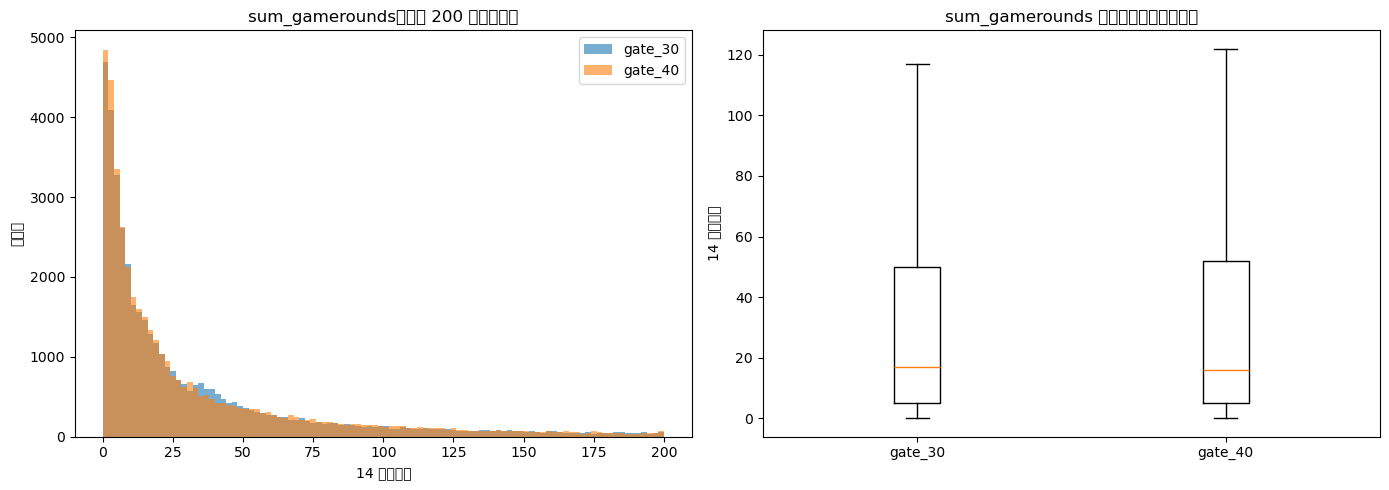


Mann-Whitney U（检验随机占优，不是均值差）
U = 1024285762
p = 0.050892
CLES = 0.5038（无差异时为 0.5）
中位数: gate_30=17, gate_40=16


In [17]:
from scipy.stats import mannwhitneyu

control = df[df["version"] == "gate_30"]["sum_gamerounds"]
treatment = df[df["version"] == "gate_40"]["sum_gamerounds"]

print(
    pd.DataFrame({"gate_30": control.describe(), "gate_40": treatment.describe()})
)
print(f"偏度: gate_30={control.skew():.2f}, gate_40={treatment.skew():.2f}")
print(
    f"中位数差 (gate_40 - gate_30) = {treatment.median() - control.median():+.0f} 局"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(control, bins=100, range=(0, 200), alpha=0.6, label="gate_30")
axes[0].hist(treatment, bins=100, range=(0, 200), alpha=0.6, label="gate_40")
axes[0].set_title("sum_gamerounds（截到 200 局看主体）")
axes[0].set_xlabel("14 天总局数")
axes[0].set_ylabel("用户数")
axes[0].legend()
axes[1].boxplot([control, treatment], showfliers=False)
axes[1].set_xticklabels(["gate_30", "gate_40"])
axes[1].set_title("sum_gamerounds 箱线图（不含离群点）")
axes[1].set_ylabel("14 天总局数")
plt.tight_layout()
plt.show()

u_stat, u_p = mannwhitneyu(control, treatment, alternative="two-sided")
cles = u_stat / (len(control) * len(treatment))  # 无差异时为 0.5

print("\nMann-Whitney U（检验随机占优，不是均值差）")
print(f"U = {u_stat:.0f}")
print(f"p = {u_p:.6f}")
print(f"CLES = {cles:.4f}（无差异时为 0.5）")
print(f"中位数: gate_30={control.median():.0f}, gate_40={treatment.median():.0f}")

p 贴着 0.05，但 CLES 几乎等于 0.5、中位数只差 1 局，参与度没有实质差异；七日留存下降不宜归因于「gate_40 玩得更少」。

可能归因1：gate_40 的 7 日留存下降，不是因为玩家玩的局数更少，而是长期体验变差导致回访减少。  
可能归因2：更晚遇到强制等待，更少人养成「过门—等待—回来」的节奏。

## 下钻分析

决策用 ITT；六成看不到门所以效应会被稀释；不能改成只分析打到门的人；若要探索，用同一条 ≥30 门槛看方向是否一致。